[1.         0.99999995 0.9999999  ... 0.9995001  0.99950005 0.9995    ]


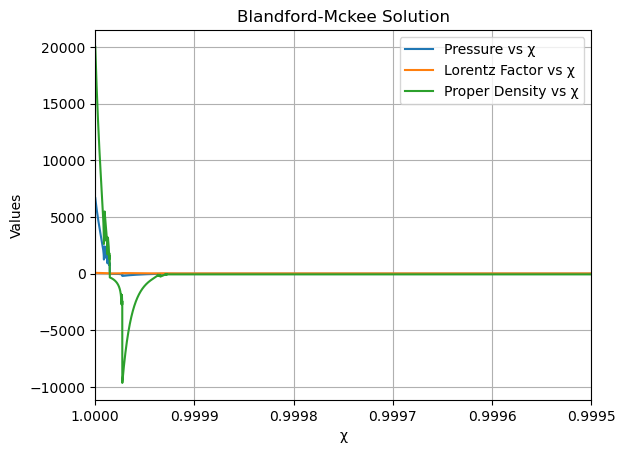

In [14]:
#ds = np.loadtxt('./bm_solution.txt')

import numpy as np
ds = np.loadtxt('bm_solution_m3_k0.txt')  # Load the data from the text file

chi_vals = ds[:, 0]
p_chi = ds[:, 1]
gamma_chi = ds[:, 2]
n_chi = ds[:, 3]
# r_chi = ds[:, 4]
# f_chi = ds[:, 5]
# g_chi = ds[:, 6]
# h_chi = ds[:, 7]
chi_vals = chi_vals[~np.isnan(chi_vals)]  # Remove NaN values
#f_chi = f_chi[~np.isnan(f_chi)]
#g_chi = g_chi[~np.isnan(g_chi)]
#h_chi = h_chi[~np.isnan(h_chi)]
n_chi = n_chi[~np.isnan(n_chi)]
p_chi = p_chi[~np.isnan(p_chi)]
gamma_chi = gamma_chi[~np.isnan(gamma_chi)]
import numpy as np
import matplotlib.pyplot as plt 

plt.plot(chi_vals, p_chi, label='Pressure vs χ')
plt.plot(chi_vals, gamma_chi, label='Lorentz Factor vs χ')
plt.plot(chi_vals, n_chi, label='Proper Density vs χ')
print(chi_vals)
plt.xlabel('χ')
plt.xlim(1, 0.9995)
plt.ylabel('Values')
plt.title('Blandford-Mckee Solution')
plt.legend()
plt.grid()
plt.show()

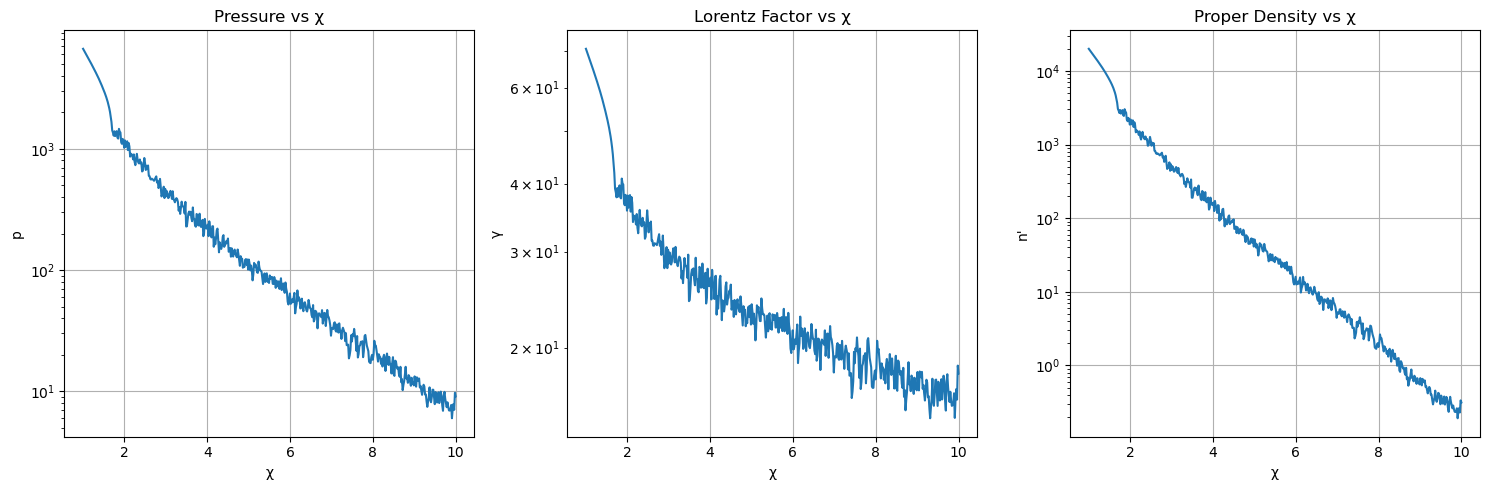

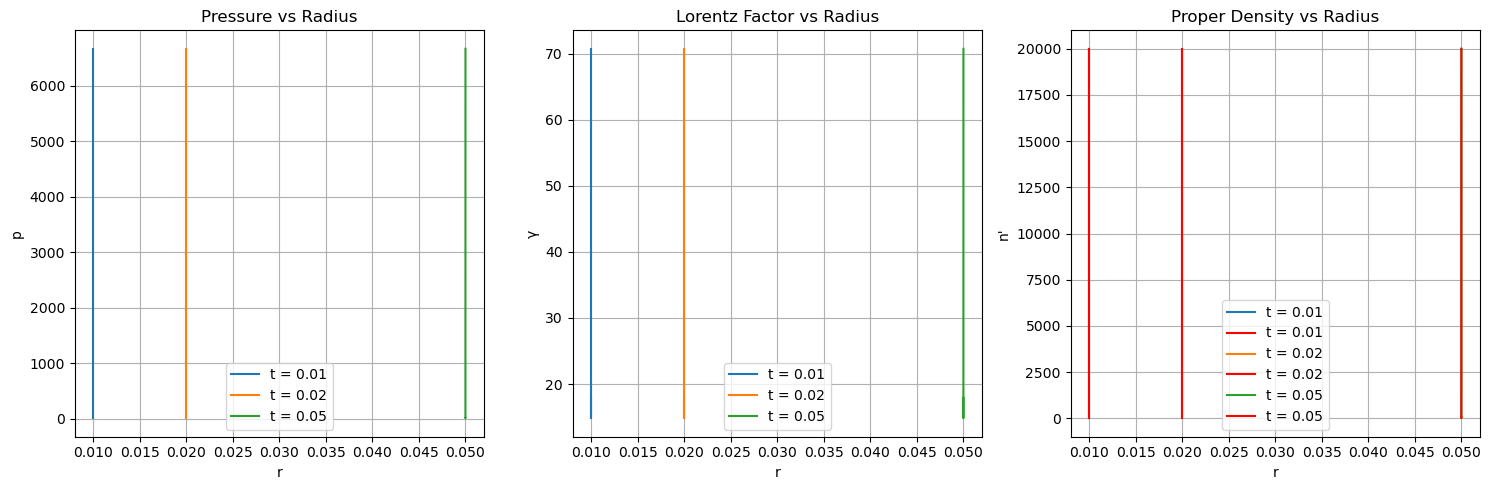

In [6]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Parameters
m = 3              # Uniform density medium
Gamma = 100        # Shock Lorentz factor
w1 = 1.0           # External enthalpy density
n1 = 1.0           # External number density

# BM ODE system
def bm_rhs(chi, y):
    f, g, h = y
    if g == 0:
        return [0, 0, 0]

    denom = (m + 1) * (4 - 8 * g * chi + g**2 * chi**2)
    dlnf_dchi = (8*(m - 1) - (m - 4) * g * chi) / denom
    dlng_dchi = ((7*m - 4) - (m + 2) * g * chi) / denom
    denom_h = denom * (2 - g * chi)
    dlnh_dchi = (2*(9*m - 8) - 2*(5*m - 6) * g * chi + (m - 2) * g**2 * chi**2) / denom_h

    return [f * dlnf_dchi, g * dlng_dchi, h * dlnh_dchi]

# Initial values at shock front
chi0 = 1.0
f0 = g0 = h0 = 1.0
y0 = [f0, g0, h0]

# Integration range in χ
chi_max = 10
chi_vals = np.linspace(chi0, chi_max, 500)

# Solve ODE
sol = solve_ivp(bm_rhs, [chi0, chi_max], y0, t_eval=chi_vals, method='RK45')
f_vals, g_vals, h_vals = sol.y

# Derived variables vs. χ
p_chi = (2/3) * w1 * Gamma**2 * f_vals
gamma_chi = np.sqrt(0.5 * Gamma**2 * g_vals)
n_chi = 2 * n1 * Gamma**2 * h_vals

# Plot vs. χ
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(chi_vals, p_chi)
plt.title('Pressure vs χ')
plt.yscale('log')
plt.xlabel('χ'); plt.ylabel('p'); plt.grid()

plt.subplot(1, 3, 2)
plt.plot(chi_vals, gamma_chi)
plt.title('Lorentz Factor vs χ')
plt.yscale('log')
plt.xlabel('χ'); plt.ylabel('γ'); plt.grid()

plt.subplot(1, 3, 3)
plt.plot(chi_vals, n_chi)
plt.title('Proper Density vs χ')
plt.yscale('log')
plt.xlabel('χ'); plt.ylabel("n'"); plt.grid()

plt.tight_layout()
plt.show()

# Plot vs. radius at different times
times = [0.01, 0.02, 0.05]
plt.figure(figsize=(15, 5))

for i, t in enumerate(times):
    xi = (chi_vals - 1) / (2 * (m + 1))
    r = t * (1 - xi / Gamma**2)
    
    p = (2/3) * w1 * Gamma**2 * f_vals
    gamma = np.sqrt(0.5 * Gamma**2 * g_vals)
    n = 2 * n1 * Gamma**2 * h_vals

    # Plot p(r)
    plt.subplot(1, 3, 1)
    plt.plot(r, p, label=f't = {t}')
    plt.xlabel('r'); plt.ylabel('p'); plt.title('Pressure vs Radius')
    plt.grid(); plt.legend()

    # Plot γ(r)
    plt.subplot(1, 3, 2)
    plt.plot(r, gamma, label=f't = {t}')
    #plt.xscale('log')
    plt.xlabel('r'); plt.ylabel('γ'); plt.title('Lorentz Factor vs Radius')
    plt.grid(); plt.legend()

    # Plot n(r)
    plt.subplot(1, 3, 3)
    plt.plot(r, n, label=f't = {t}')
    plt.plot(r, 3*p, c='r',label=f't = {t}')
    plt.xlabel('r'); plt.ylabel("n'"); plt.title("Proper Density vs Radius")
    plt.grid(); plt.legend()

plt.tight_layout()
plt.show()

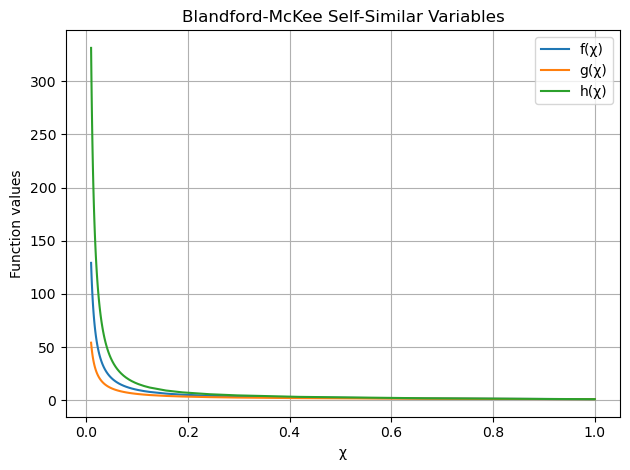

In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Parameter m (commonly 3 for uniform medium)
m = 3

# System of ODEs: df/dχ, dg/dχ, dh/dχ
def bm_rhs(chi, y):
    f, g, h = y
    # Avoid division by zero or singularities
    if chi == 0 or g == 0:
        return [0, 0, 0]
    
    denom = (m + 1) * (4 - 8 * g * chi + g**2 * chi**2)
    
    dlnf_dchi = (8*(m-1) - (m-4)*g*chi) / denom
    dlng_dchi = ((7*m - 4) - (m + 2)*g*chi) / denom
    
    # Denominator for dlnh/dχ has an extra (2 - gχ) term
    denom_h = denom * (2 - g * chi)
    dlnh_dchi = (2*(9*m - 8) - 2*(5*m - 6)*g*chi + (m - 2)*g**2 * chi**2) / denom_h

    # Chain rule: dy/dχ = y * dlny/dχ
    df_dchi = f * dlnf_dchi
    dg_dchi = g * dlng_dchi
    dh_dchi = h * dlnh_dchi

    return [df_dchi, dg_dchi, dh_dchi]

# Initial conditions at chi = 1 (shock front)
chi0 = 1.0
f0 = 1.0
g0 = 1.0
h0 = 1.0

# Range of chi (integration backward toward the origin)
chi_span = [1.0, 0.01]
y0 = [f0, g0, h0]

# Solve the system
sol = solve_ivp(bm_rhs, chi_span, y0, method='RK45', dense_output=True)

# Plotting the result
chi_vals = sol.t
f_vals, g_vals, h_vals = sol.y

plt.plot(chi_vals, f_vals, label='f(χ)')
plt.plot(chi_vals, g_vals, label='g(χ)')
plt.plot(chi_vals, h_vals, label='h(χ)')
#plt.gca().invert_xaxis()  # Optional: plot from shock inward
plt.xlabel('χ')
plt.ylabel('Function values')
plt.title('Blandford-McKee Self-Similar Variables')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

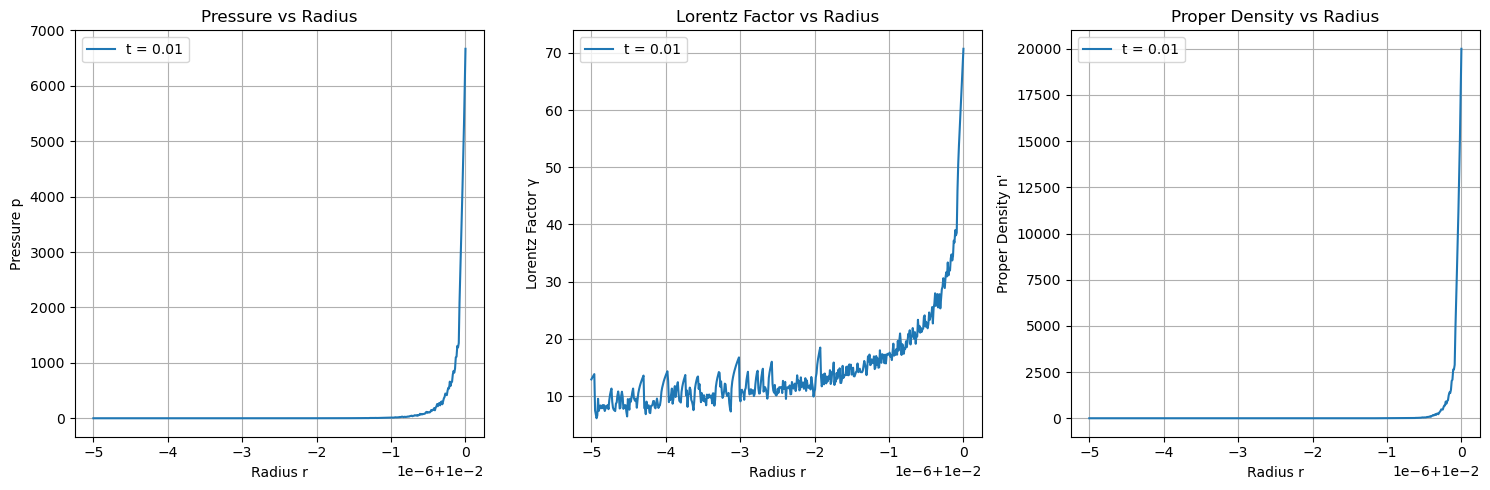

In [3]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Parameters
m = 3              # Power-law index of ambient density
Gamma = 100        # Shock Lorentz factor
w1 = 1.0           # Upstream enthalpy density
n1 = 1.0           # Upstream number density

# Blandford-McKee ODEs
def bm_rhs(chi, y):
    f, g, h = y
    if g == 0:
        return [0, 0, 0]

    denom = (m + 1) * (4 - 8 * g * chi + g**2 * chi**2)
    dlnf_dchi = (8*(m - 1) - (m - 4) * g * chi) / denom
    dlng_dchi = ((7*m - 4) - (m + 2) * g * chi) / denom
    denom_h = denom * (2 - g * chi)
    dlnh_dchi = (2*(9*m - 8) - 2*(5*m - 6) * g * chi + (m - 2) * g**2 * chi**2) / denom_h

    return [f * dlnf_dchi, g * dlng_dchi, h * dlnh_dchi]

# Initial conditions at shock front (chi = 1)
chi0 = 1.0
f0 = 1.0
g0 = 1.0
h0 = 1.0
y0 = [f0, g0, h0]

# Integration range
chi_max = 1 + 2 * (m + 1) * 5  # Choose a large enough domain in χ
chi_vals = np.linspace(chi0, chi_max, 500)

# Solve the system
sol = solve_ivp(bm_rhs, [chi0, chi_max], y0, t_eval=chi_vals, method='RK45')
f_vals, g_vals, h_vals = sol.y

# Convert χ to radius r at different times
times = [0.01] #, 0.02, 0.05]  # Example times
r_profiles = []
p_profiles = []
gamma_profiles = []
n_profiles = []

for t in times:
    xi = (chi_vals - 1) / (2 * (m + 1))
    r = t * (1 - xi / Gamma**2)
    
    p = (2/3) * w1 * Gamma**2 * f_vals
    gamma = np.sqrt(0.5 * Gamma**2 * g_vals)
    n = 2 * n1 * Gamma**2 * h_vals

    r_profiles.append(r)
    p_profiles.append(p)
    gamma_profiles.append(gamma)
    n_profiles.append(n)

# Plotting
plt.figure(figsize=(15, 5))

# Pressure
plt.subplot(1, 3, 1)
for i, t in enumerate(times):
    plt.plot(r_profiles[i], p_profiles[i], label=f't = {t}')
plt.xlabel('Radius r')
plt.ylabel('Pressure p')
plt.title('Pressure vs Radius')
plt.legend()
plt.grid()

# Lorentz factor
plt.subplot(1, 3, 2)
for i, t in enumerate(times):
    plt.plot(r_profiles[i], gamma_profiles[i], label=f't = {t}')
plt.xlabel('Radius r')
plt.ylabel('Lorentz Factor γ')
plt.title('Lorentz Factor vs Radius')
plt.legend()
plt.grid()

# Proper density
plt.subplot(1, 3, 3)
for i, t in enumerate(times):
    plt.plot(r_profiles[i], n_profiles[i], label=f't = {t}')
plt.xlabel('Radius r')
plt.ylabel("Proper Density n'")
plt.title("Proper Density vs Radius")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# Base Code for Producing Graphs

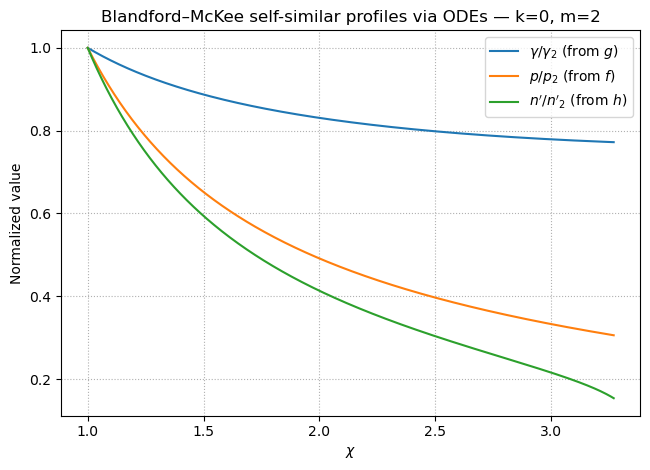

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
from dataclasses import dataclass
from scipy.integrate import solve_ivp

# -------------------------------
# Problem setup / parameters
# -------------------------------
@dataclass
class BMParams:
    m: float = 3.0   # deceleration index (Gamma^2 ∝ t^{-m}); m=3 for adiabatic, k=0
    k: float = 0.0   # external density profile rho ∝ r^{-k}; k=0 uniform
    eps: float = 1e-5  # start just behind the shock at chi = 1 + eps
    chimax: float = 10.0  # target max chi (may stop earlier due to event)
    rtol: float = 1e-6    # slightly looser to start; tighten after it's stable
    atol: float = 1e-9

# -------------------------------
# BM76 ODEs (eqs. 35–37): df/dchi, dg/dchi, dh/dchi
# -------------------------------
def bm76_rhs(chi, y, m, k):
    f, g, h = y

    # Common denominator
    D = (m + 1.0) * (4.0 - 8.0*g*chi + (g**2)*(chi**2))

    # Numerators from BM76 (generic m,k form)
    A = 4.0*(2*(m - 1.0) + k) - (m + k - 4.0)*g*chi
    B = (7.0*m + 3.0*k - 4.0) - (m + 2.0)*g*chi
    C = 2.0*(9.0*m + 5.0*k - 8.0) - 2.0*(5.0*m + 4.0*k - 6.0)*g*chi + (m + k - 2.0)*(g**2)*(chi**2)

    # Convert BM log-derivatives to df/dchi etc.
    df_dchi = f * g * A / D
    dg_dchi = (g**2) * B / D
    dh_dchi = h * g * C / (D * (2.0 - g*chi))
    return np.array([df_dchi, dg_dchi, dh_dchi])

# -------------------------------
# Event: stop before D -> 0 (critical surface)
# -------------------------------
def make_event_stop_before_D_zero(m, k, margin=1e-3):
    """
    Stop when 4 - 8(g*chi) + (g*chi)^2 ~ margin > 0 (approaching 0 from above).
    """
    def event(ch, y):
        _, g, _ = y
        x = g * ch
        return (4.0 - 8.0*x + x*x) - margin
    event.terminal = True
    event.direction = -1.0   # trigger when decreasing through margin
    return event

# Optional extra safety: stop if 2 - g*chi gets small (shouldn't happen for m<=3, k=0)
def make_event_stop_before_h_den(margin=5e-2):
    def event(ch, y):
        _, g, _ = y
        x = g * ch
        return (2.0 - x) - margin
    event.terminal = True
    event.direction = -1.0
    return event

# -------------------------------
# Integrate from chi = 1+eps to chimax (or earlier if event triggers)
# -------------------------------
def integrate_fgH(params):
    chi0 = 1.0 + params.eps
    y0   = np.array([1.0, 1.0, 1.0])  # f(1)=g(1)=h(1)=1

    ev1 = make_event_stop_before_D_zero(params.m, params.k, margin=1e-3)
    ev2 = make_event_stop_before_h_den(margin=5e-2)

    sol = solve_ivp(
        fun=lambda ch, y: bm76_rhs(ch, y, params.m, params.k),
        t_span=(chi0, params.chimax),
        y0=y0,
        method="Radau",                   # Radau handles the stiffness nicely
        dense_output=True,
        rtol=params.rtol,
        atol=params.atol,
        max_step=(params.chimax - chi0)/4000.0,
        events=[ev1, ev2]
    )

    # Accept if solver succeeded OR it hit an event (typical)
    if (not sol.success) and all(len(te)==0 for te in sol.t_events):
        raise RuntimeError(sol.message)
    return sol

# -------------------------------
# Make the Figure 1–style plot using f,g,h
# -------------------------------
def plot_profiles(sol, params, title_suffix=None):
    # determine the actual end of valid solution
    chi_end = sol.t[-1]
    for te in sol.t_events:
        if len(te):
            chi_end = min(chi_end, te[-1])

    chi = np.logspace(np.log10(1.0+params.eps), np.log10(chi_end), 600)
    f, g, h = sol.sol(chi)

    # lock left edge exactly to 1 to remove tiny drift
    f /= f[0]; g /= g[0]; h /= h[0]

    gamma_norm = np.sqrt(g)   # γ/γ2
    p_norm     = f            # p/p2
    n_norm     = h            # n'/n'2

    if title_suffix is None:
        title_suffix = f"k={params.k:g}, m={params.m:g}"

    plt.figure(figsize=(6.6,4.8))
    plt.plot(chi, gamma_norm, label=r'$\gamma/\gamma_2$ (from $g$)')
    plt.plot(chi, p_norm,     label=r'$p/p_2$ (from $f$)')
    plt.plot(chi, n_norm,     label=r"$n'/n'_2$ (from $h$)")
    plt.xlabel(r'$\chi$')
    plt.ylabel('Normalized value')
    plt.title(f'Blandford–McKee self-similar profiles via ODEs — {title_suffix}')
    plt.grid(True, which='both', ls=':')
    plt.legend()
    plt.tight_layout()
    plt.show()

# -------------------------------
# Run (example: m=1, k=0 like you had)
# -------------------------------
P = BMParams(m=2, k=0)   # also try m=2, k=0
sol = integrate_fgH(P)
plot_profiles(sol, P)


# Conditions for the following three figures

(1) m = 3, impulsive energy injection in a uniform medium

(2) m = 2, energy injection $L \propto t_e^{-2/3}$

(3) m = 1, k =2 , impulsive energy injection in a nonrelativistic constant velocity wind

## Normalized Pressure behind the Shock Front 

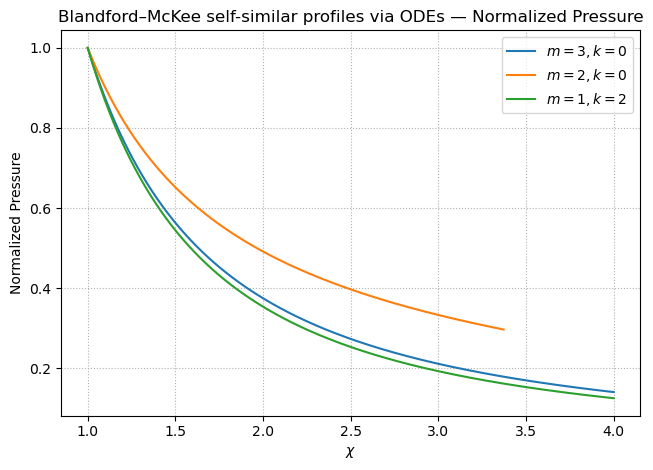

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
from dataclasses import dataclass
from scipy.integrate import solve_ivp

# -------------------------------
# Problem setup / parameters
# -------------------------------
@dataclass
class BMParams:
    m: float = 3.0   # deceleration index (Gamma^2 ∝ t^{-m}); m=3 for adiabatic, k=0
    k: float = 0.0   # external density profile rho ∝ r^{-k}; k=0 uniform
    eps: float = 1e-5  # start just behind the shock at chi = 1 + eps
    chimax: float = 4.0  # target max chi (may stop earlier due to event)
    rtol: float = 1e-6    # slightly looser to start; tighten after it's stable
    atol: float = 1e-9

# -------------------------------
# BM76 ODEs (eqs. 35–37): df/dchi, dg/dchi, dh/dchi
# -------------------------------
def bm76_rhs(chi, y, m, k):
    f, g, h = y

    # Common denominator
    D = (m + 1.0) * (4.0 - 8.0*g*chi + (g**2)*(chi**2))

    # Numerators from BM76 (generic m,k form)
    A = 4.0*(2*(m - 1.0) + k) - (m + k - 4.0)*g*chi
    B = (7.0*m + 3.0*k - 4.0) - (m + 2.0)*g*chi
    C = 2.0*(9.0*m + 5.0*k - 8.0) - 2.0*(5.0*m + 4.0*k - 6.0)*g*chi + (m + k - 2.0)*(g**2)*(chi**2)

    # Convert BM log-derivatives to df/dchi etc.
    df_dchi = f * g * A / D
    dg_dchi = (g**2) * B / D
    dh_dchi = h * g * C / (D * (2.0 - g*chi))
    return np.array([df_dchi, dg_dchi, dh_dchi])

# -------------------------------
# Event: stop before D -> 0 (critical surface)
# -------------------------------
def make_event_stop_before_D_zero(m, k, margin=1e-3):
    """
    Stop when 4 - 8(g*chi) + (g*chi)^2 ~ margin > 0 (approaching 0 from above).
    """
    def event(ch, y):
        _, g, _ = y
        x = g * ch
        return (4.0 - 8.0*x + x*x) - margin
    event.terminal = True
    event.direction = -1.0   # trigger when decreasing through margin
    return event

# Optional extra safety: stop if 2 - g*chi gets small (shouldn't happen for m<=3, k=0)
def make_event_stop_before_h_den(margin=5e-2):
    def event(ch, y):
        _, g, _ = y
        x = g * ch
        return (2.0 - x) - margin
    event.terminal = True
    event.direction = -1.0
    return event

# -------------------------------
# Integrate from chi = 1+eps to chimax (or earlier if event triggers)
# -------------------------------
def integrate_fgH(params):
    chi0 = 1.0 + params.eps
    y0   = np.array([1.0, 1.0, 1.0])  # f(1)=g(1)=h(1)=1

    ev1 = make_event_stop_before_D_zero(params.m, params.k, margin=1e-4)
    ev2 = make_event_stop_before_h_den(margin=1e-4)

    sol = solve_ivp(
        fun=lambda ch, y: bm76_rhs(ch, y, params.m, params.k),
        t_span=(chi0, params.chimax),
        y0=y0,
        method="Radau",                   # Radau handles the stiffness nicely
        dense_output=True,
        rtol=params.rtol,
        atol=params.atol,
        max_step=(params.chimax - chi0)/4000.0,
        events=[ev1, ev2]
    )

    # Accept if solver succeeded OR it hit an event (typical)
    if (not sol.success) and all(len(te)==0 for te in sol.t_events):
        raise RuntimeError(sol.message)
    return sol

# -------------------------------
# Make the Figure 1–style plot using f,g,h
# -------------------------------
def plot_profiles(sol1,sol2,sol3, params1,params2,params3,title_suffix=None):
    # determine the actual end of valid solution
    chi_end1 = sol1.t[-1]
    for te in sol1.t_events:
        if len(te):
            chi_end1 = min(chi_end1, te[-1])

    chi_end2 = sol2.t[-1]
    for te in sol2.t_events:
        if len(te):
            chi_end2 = min(chi_end2, te[-1])

    chi_end3 = sol3.t[-1]
    for te in sol3.t_events:
        if len(te):
            chi_end3 = min(chi_end3, te[-1])


    chi1 = np.logspace(np.log10(1.0+params1.eps), np.log10(chi_end1), 600)
    f1, g1, h1 = sol1.sol(chi1)

    # lock left edge exactly to 1 to remove tiny drift
    # f1 /= f1[0]; g1 /= g1[0]; h1 /= h1[0]

    chi2 = np.logspace(np.log10(1.0+params2.eps), np.log10(chi_end2), 600)
    f2, g2, h2 = sol2.sol(chi2)

    # f2 /= f2[0]; g2 /= g2[0]; h2 /= h2[0]

    chi3 = np.logspace(np.log10(1.0+params3.eps), np.log10(chi_end3), 600)
    f3, g3, h3 = sol3.sol(chi3)

    # f3 /= f3[0]; g3 /= g3[0]; h3 /= h3[0]

    gamma_norm1 = np.sqrt(g1)   # γ/γ2
    p_norm1     = f1            # p/p2
    n_norm1     = h1

    gamma_norm2 = np.sqrt(g2)   # γ/γ2
    p_norm2     = f2            # p/p2
    n_norm2     = h2

    gamma_norm3 = np.sqrt(g3)   # γ/γ2
    p_norm3     = f3            # p/p2
    n_norm3     = h3

    plt.figure(figsize=(6.6,4.8))
    plt.plot(chi1, p_norm1, label=r'$m=3,k=0$')
    plt.plot(chi2, p_norm2,     label=r'$m=2,k=0$')
    plt.plot(chi3, p_norm3,     label=r"$m=1,k=2$")
    plt.xlabel(r'$\chi$')
    plt.ylabel('Normalized Pressure')
    plt.title(f'Blandford–McKee self-similar profiles via ODEs — Normalized Pressure')
    plt.grid(True, which='both', ls=':')
    plt.legend()
    plt.tight_layout()
    plt.show()

P1 = BMParams(m=3, k=0)  
sol1 = integrate_fgH(P1)
P2 = BMParams(m=2, k=0)
sol2 = integrate_fgH(P2)
P3 = BMParams(m=1, k=2)
sol3 = integrate_fgH(P3)
plot_profiles(sol1,sol2,sol3, P1,P2,P3)


## Normalized Density

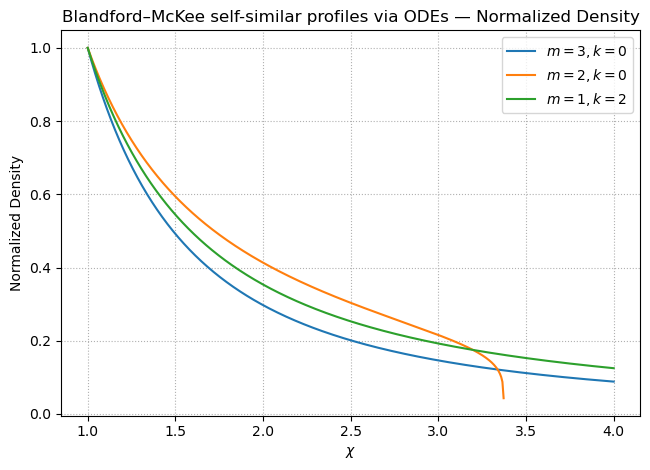

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
from dataclasses import dataclass
from scipy.integrate import solve_ivp

# -------------------------------
# Problem setup / parameters
# -------------------------------
@dataclass
class BMParams:
    m: float = 3.0   # deceleration index (Gamma^2 ∝ t^{-m}); m=3 for adiabatic, k=0
    k: float = 0.0   # external density profile rho ∝ r^{-k}; k=0 uniform
    eps: float = 1e-5  # start just behind the shock at chi = 1 + eps
    chimax: float = 4.0  # target max chi (may stop earlier due to event)
    rtol: float = 1e-6    # slightly looser to start; tighten after it's stable
    atol: float = 1e-9

# -------------------------------
# BM76 ODEs (eqs. 35–37): df/dchi, dg/dchi, dh/dchi
# -------------------------------
def bm76_rhs(chi, y, m, k):
    f, g, h = y

    # Common denominator
    D = (m + 1.0) * (4.0 - 8.0*g*chi + (g**2)*(chi**2))

    # Numerators from BM76 (generic m,k form)
    A = 4.0*(2*(m - 1.0) + k) - (m + k - 4.0)*g*chi
    B = (7.0*m + 3.0*k - 4.0) - (m + 2.0)*g*chi
    C = 2.0*(9.0*m + 5.0*k - 8.0) - 2.0*(5.0*m + 4.0*k - 6.0)*g*chi + (m + k - 2.0)*(g**2)*(chi**2)

    # Convert BM log-derivatives to df/dchi etc.
    df_dchi = f * g * A / D
    dg_dchi = (g**2) * B / D
    dh_dchi = h * g * C / (D * (2.0 - g*chi))
    return np.array([df_dchi, dg_dchi, dh_dchi])

# -------------------------------
# Event: stop before D -> 0 (critical surface)
# -------------------------------
def make_event_stop_before_D_zero(m, k, margin=1e-3):
    """
    Stop when 4 - 8(g*chi) + (g*chi)^2 ~ margin > 0 (approaching 0 from above).
    """
    def event(ch, y):
        _, g, _ = y
        x = g * ch
        return (4.0 - 8.0*x + x*x) - margin
    event.terminal = True
    event.direction = -1.0   # trigger when decreasing through margin
    return event

# Optional extra safety: stop if 2 - g*chi gets small (shouldn't happen for m<=3, k=0)
def make_event_stop_before_h_den(margin=5e-2):
    def event(ch, y):
        _, g, _ = y
        x = g * ch
        return (2.0 - x) - margin
    event.terminal = True
    event.direction = -1.0
    return event

# -------------------------------
# Integrate from chi = 1+eps to chimax (or earlier if event triggers)
# -------------------------------
def integrate_fgH(params):
    chi0 = 1.0 + params.eps
    y0   = np.array([1.0, 1.0, 1.0])  # f(1)=g(1)=h(1)=1

    ev1 = make_event_stop_before_D_zero(params.m, params.k, margin=1e-4)
    ev2 = make_event_stop_before_h_den(margin=1e-4)

    sol = solve_ivp(
        fun=lambda ch, y: bm76_rhs(ch, y, params.m, params.k),
        t_span=(chi0, params.chimax),
        y0=y0,
        method="Radau",                   # Radau handles the stiffness nicely
        dense_output=True,
        rtol=params.rtol,
        atol=params.atol,
        max_step=(params.chimax - chi0)/4000.0,
        events=[ev1, ev2]
    )

    # Accept if solver succeeded OR it hit an event (typical)
    if (not sol.success) and all(len(te)==0 for te in sol.t_events):
        raise RuntimeError(sol.message)
    return sol

# -------------------------------
# Make the Figure 1–style plot using f,g,h
# -------------------------------
def plot_profiles(sol1,sol2,sol3, params1,params2,params3,title_suffix=None):
    # determine the actual end of valid solution
    chi_end1 = sol1.t[-1]
    for te in sol1.t_events:
        if len(te):
            chi_end1 = min(chi_end1, te[-1])

    chi_end2 = sol2.t[-1]
    for te in sol2.t_events:
        if len(te):
            chi_end2 = min(chi_end2, te[-1])

    chi_end3 = sol3.t[-1]
    for te in sol3.t_events:
        if len(te):
            chi_end3 = min(chi_end3, te[-1])


    chi1 = np.logspace(np.log10(1.0+params1.eps), np.log10(chi_end1), 600)
    f1, g1, h1 = sol1.sol(chi1)

    # lock left edge exactly to 1 to remove tiny drift
    # f1 /= f1[0]; g1 /= g1[0]; h1 /= h1[0]

    chi2 = np.logspace(np.log10(1.0+params2.eps), np.log10(chi_end2), 600)
    f2, g2, h2 = sol2.sol(chi2)

    # f2 /= f2[0]; g2 /= g2[0]; h2 /= h2[0]

    chi3 = np.logspace(np.log10(1.0+params3.eps), np.log10(chi_end3), 600)
    f3, g3, h3 = sol3.sol(chi3)

    # f3 /= f3[0]; g3 /= g3[0]; h3 /= h3[0]

    gamma_norm1 = np.sqrt(g1)   # γ/γ2
    p_norm1     = f1            # p/p2
    n_norm1     = h1

    gamma_norm2 = np.sqrt(g2)   # γ/γ2
    p_norm2     = f2            # p/p2
    n_norm2     = h2

    gamma_norm3 = np.sqrt(g3)   # γ/γ2
    p_norm3     = f3            # p/p2
    n_norm3     = h3

    plt.figure(figsize=(6.6,4.8))
    plt.plot(chi1, n_norm1, label=r'$m=3,k=0$')
    plt.plot(chi2, n_norm2,     label=r'$m=2,k=0$')
    plt.plot(chi3, n_norm3,     label=r"$m=1,k=2$")
    plt.xlabel(r'$\chi$')
    plt.ylabel('Normalized Density')
    plt.title(f'Blandford–McKee self-similar profiles via ODEs — Normalized Density')
    plt.grid(True, which='both', ls=':')
    plt.legend()
    plt.tight_layout()
    plt.show()

P1 = BMParams(m=3, k=0)  
sol1 = integrate_fgH(P1)
P2 = BMParams(m=2, k=0)
sol2 = integrate_fgH(P2)
P3 = BMParams(m=1, k=2)
sol3 = integrate_fgH(P3)
plot_profiles(sol1,sol2,sol3, P1,P2,P3)


## Lorentz Factor

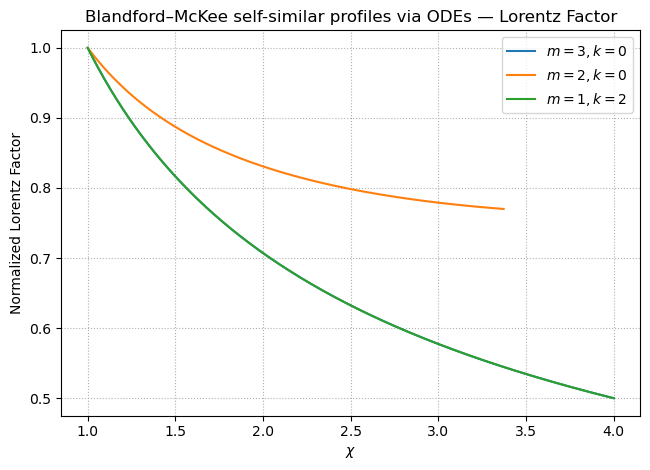

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
from dataclasses import dataclass
from scipy.integrate import solve_ivp

# -------------------------------
# Problem setup / parameters
# -------------------------------
@dataclass
class BMParams:
    m: float = 3.0   # deceleration index (Gamma^2 ∝ t^{-m}); m=3 for adiabatic, k=0
    k: float = 0.0   # external density profile rho ∝ r^{-k}; k=0 uniform
    eps: float = 1e-5  # start just behind the shock at chi = 1 + eps
    chimax: float = 4.0  # target max chi (may stop earlier due to event)
    rtol: float = 1e-6    # slightly looser to start; tighten after it's stable
    atol: float = 1e-9

# -------------------------------
# BM76 ODEs (eqs. 35–37): df/dchi, dg/dchi, dh/dchi
# -------------------------------
def bm76_rhs(chi, y, m, k):
    f, g, h = y

    # Common denominator
    D = (m + 1.0) * (4.0 - 8.0*g*chi + (g**2)*(chi**2))

    # Numerators from BM76 (generic m,k form)
    A = 4.0*(2*(m - 1.0) + k) - (m + k - 4.0)*g*chi
    B = (7.0*m + 3.0*k - 4.0) - (m + 2.0)*g*chi
    C = 2.0*(9.0*m + 5.0*k - 8.0) - 2.0*(5.0*m + 4.0*k - 6.0)*g*chi + (m + k - 2.0)*(g**2)*(chi**2)

    # Convert BM log-derivatives to df/dchi etc.
    df_dchi = f * g * A / D
    dg_dchi = (g**2) * B / D
    dh_dchi = h * g * C / (D * (2.0 - g*chi))
    return np.array([df_dchi, dg_dchi, dh_dchi])

# -------------------------------
# Event: stop before D -> 0 (critical surface)
# -------------------------------
def make_event_stop_before_D_zero(m, k, margin=1e-3):
    """
    Stop when 4 - 8(g*chi) + (g*chi)^2 ~ margin > 0 (approaching 0 from above).
    """
    def event(ch, y):
        _, g, _ = y
        x = g * ch
        return (4.0 - 8.0*x + x*x) - margin
    event.terminal = True
    event.direction = -1.0   # trigger when decreasing through margin
    return event

# Optional extra safety: stop if 2 - g*chi gets small (shouldn't happen for m<=3, k=0)
def make_event_stop_before_h_den(margin=5e-2):
    def event(ch, y):
        _, g, _ = y
        x = g * ch
        return (2.0 - x) - margin
    event.terminal = True
    event.direction = -1.0
    return event

# -------------------------------
# Integrate from chi = 1+eps to chimax (or earlier if event triggers)
# -------------------------------
def integrate_fgH(params):
    chi0 = 1.0 + params.eps
    y0   = np.array([1.0, 1.0, 1.0])  # f(1)=g(1)=h(1)=1

    ev1 = make_event_stop_before_D_zero(params.m, params.k, margin=1e-4)
    ev2 = make_event_stop_before_h_den(margin=1e-4)

    sol = solve_ivp(
        fun=lambda ch, y: bm76_rhs(ch, y, params.m, params.k),
        t_span=(chi0, params.chimax),
        y0=y0,
        method="Radau",                   # Radau handles the stiffness nicely
        dense_output=True,
        rtol=params.rtol,
        atol=params.atol,
        max_step=(params.chimax - chi0)/4000.0,
        events=[ev1, ev2]
    )

    # Accept if solver succeeded OR it hit an event (typical)
    if (not sol.success) and all(len(te)==0 for te in sol.t_events):
        raise RuntimeError(sol.message)
    return sol

# -------------------------------
# Make the Figure 1–style plot using f,g,h
# -------------------------------
def plot_profiles(sol1,sol2,sol3, params1,params2,params3,title_suffix=None):
    # determine the actual end of valid solution
    chi_end1 = sol1.t[-1]
    for te in sol1.t_events:
        if len(te):
            chi_end1 = min(chi_end1, te[-1])

    chi_end2 = sol2.t[-1]
    for te in sol2.t_events:
        if len(te):
            chi_end2 = min(chi_end2, te[-1])

    chi_end3 = sol3.t[-1]
    for te in sol3.t_events:
        if len(te):
            chi_end3 = min(chi_end3, te[-1])


    chi1 = np.logspace(np.log10(1.0+params1.eps), np.log10(chi_end1), 600)
    f1, g1, h1 = sol1.sol(chi1)

    # lock left edge exactly to 1 to remove tiny drift
    # f1 /= f1[0]; g1 /= g1[0]; h1 /= h1[0]

    chi2 = np.logspace(np.log10(1.0+params2.eps), np.log10(chi_end2), 600)
    f2, g2, h2 = sol2.sol(chi2)

    # f2 /= f2[0]; g2 /= g2[0]; h2 /= h2[0]

    chi3 = np.logspace(np.log10(1.0+params3.eps), np.log10(chi_end3), 600)
    f3, g3, h3 = sol3.sol(chi3)

    # f3 /= f3[0]; g3 /= g3[0]; h3 /= h3[0]

    gamma_norm1 = np.sqrt(g1)   # γ/γ2
    p_norm1     = f1            # p/p2
    n_norm1     = h1

    gamma_norm2 = np.sqrt(g2)   # γ/γ2
    p_norm2     = f2            # p/p2
    n_norm2     = h2

    gamma_norm3 = np.sqrt(g3)   # γ/γ2
    p_norm3     = f3            # p/p2
    n_norm3     = h3

    plt.figure(figsize=(6.6,4.8))
    plt.plot(chi1, gamma_norm1, label=r'$m=3,k=0$')
    plt.plot(chi2, gamma_norm2,     label=r'$m=2,k=0$')
    plt.plot(chi3, gamma_norm3,     label=r"$m=1,k=2$")
    plt.xlabel(r'$\chi$')
    plt.ylabel('Normalized Lorentz Factor')
    plt.title(f'Blandford–McKee self-similar profiles via ODEs — Lorentz Factor')
    plt.grid(True, which='both', ls=':')
    plt.legend()
    plt.tight_layout()
    plt.show()

P1 = BMParams(m=3, k=0)  
sol1 = integrate_fgH(P1)
P2 = BMParams(m=2, k=0)
sol2 = integrate_fgH(P2)
P3 = BMParams(m=1, k=2)
sol3 = integrate_fgH(P3)
plot_profiles(sol1,sol2,sol3, P1,P2,P3)


# Conditions for next three plots

(1) $m = 0$, energy injection $L \propto t_e^2$ in a uniform medium
(2) $m = 1$, steady energy injection $L = \mathrm{constant}$ in a uniform medium
(3) $m = 0$. $k = 2$, steady energy injection in a non-relativistic, constant velocity wind

## Normalized pressure behind the shock front

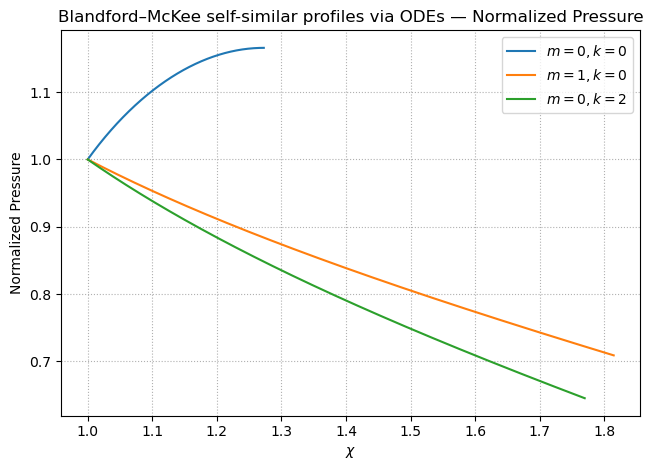

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
from dataclasses import dataclass
from scipy.integrate import solve_ivp

# -------------------------------
# Problem setup / parameters
# -------------------------------
@dataclass
class BMParams:
    m: float = 3.0   # deceleration index (Gamma^2 ∝ t^{-m}); m=3 for adiabatic, k=0
    k: float = 0.0   # external density profile rho ∝ r^{-k}; k=0 uniform
    eps: float = 1e-5  # start just behind the shock at chi = 1 + eps
    chimax: float = 4.0  # target max chi (may stop earlier due to event)
    rtol: float = 1e-6    # slightly looser to start; tighten after it's stable
    atol: float = 1e-9

# -------------------------------
# BM76 ODEs (eqs. 35–37): df/dchi, dg/dchi, dh/dchi
# -------------------------------
def bm76_rhs(chi, y, m, k):
    f, g, h = y

    # Common denominator
    D = (m + 1.0) * (4.0 - 8.0*g*chi + (g**2)*(chi**2))

    # Numerators from BM76 (generic m,k form)
    A = 4.0*(2*(m - 1.0) + k) - (m + k - 4.0)*g*chi
    B = (7.0*m + 3.0*k - 4.0) - (m + 2.0)*g*chi
    C = 2.0*(9.0*m + 5.0*k - 8.0) - 2.0*(5.0*m + 4.0*k - 6.0)*g*chi + (m + k - 2.0)*(g**2)*(chi**2)

    # Convert BM log-derivatives to df/dchi etc.
    df_dchi = f * g * A / D
    dg_dchi = (g**2) * B / D
    dh_dchi = h * g * C / (D * (2.0 - g*chi))
    return np.array([df_dchi, dg_dchi, dh_dchi])

# -------------------------------
# Event: stop before D -> 0 (critical surface)
# -------------------------------
def make_event_stop_before_D_zero(m, k, margin=1e-3):
    """
    Stop when 4 - 8(g*chi) + (g*chi)^2 ~ margin > 0 (approaching 0 from above).
    """
    def event(ch, y):
        _, g, _ = y
        x = g * ch
        return (4.0 - 8.0*x + x*x) - margin
    event.terminal = True
    event.direction = -1.0   # trigger when decreasing through margin
    return event

# Optional extra safety: stop if 2 - g*chi gets small (shouldn't happen for m<=3, k=0)
def make_event_stop_before_h_den(margin=5e-2):
    def event(ch, y):
        _, g, _ = y
        x = g * ch
        return (2.0 - x) - margin
    event.terminal = True
    event.direction = -1.0
    return event

# -------------------------------
# Integrate from chi = 1+eps to chimax (or earlier if event triggers)
# -------------------------------
def integrate_fgH(params):
    chi0 = 1.0 + params.eps
    y0   = np.array([1.0, 1.0, 1.0])  # f(1)=g(1)=h(1)=1

    ev1 = make_event_stop_before_D_zero(params.m, params.k, margin=1e-4)
    ev2 = make_event_stop_before_h_den(margin=1e-4)

    sol = solve_ivp(
        fun=lambda ch, y: bm76_rhs(ch, y, params.m, params.k),
        t_span=(chi0, params.chimax),
        y0=y0,
        method="Radau",                   # Radau handles the stiffness nicely
        dense_output=True,
        rtol=params.rtol,
        atol=params.atol,
        max_step=(params.chimax - chi0)/4000.0,
        events=[ev1, ev2]
    )

    # Accept if solver succeeded OR it hit an event (typical)
    if (not sol.success) and all(len(te)==0 for te in sol.t_events):
        raise RuntimeError(sol.message)
    return sol

# -------------------------------
# Make the Figure 1–style plot using f,g,h
# -------------------------------
def plot_profiles(sol1,sol2,sol3, params1,params2,params3,title_suffix=None):
    # determine the actual end of valid solution
    chi_end1 = sol1.t[-1]
    for te in sol1.t_events:
        if len(te):
            chi_end1 = min(chi_end1, te[-1])

    chi_end2 = sol2.t[-1]
    for te in sol2.t_events:
        if len(te):
            chi_end2 = min(chi_end2, te[-1])

    chi_end3 = sol3.t[-1]
    for te in sol3.t_events:
        if len(te):
            chi_end3 = min(chi_end3, te[-1])


    chi1 = np.logspace(np.log10(1.0+params1.eps), np.log10(chi_end1), 600)
    f1, g1, h1 = sol1.sol(chi1)

    # lock left edge exactly to 1 to remove tiny drift
    # f1 /= f1[0]; g1 /= g1[0]; h1 /= h1[0]

    chi2 = np.logspace(np.log10(1.0+params2.eps), np.log10(chi_end2), 600)
    f2, g2, h2 = sol2.sol(chi2)

    # f2 /= f2[0]; g2 /= g2[0]; h2 /= h2[0]

    chi3 = np.logspace(np.log10(1.0+params3.eps), np.log10(chi_end3), 600)
    f3, g3, h3 = sol3.sol(chi3)

    # f3 /= f3[0]; g3 /= g3[0]; h3 /= h3[0]

    gamma_norm1 = np.sqrt(g1)   # γ/γ2
    p_norm1     = f1            # p/p2
    n_norm1     = h1

    gamma_norm2 = np.sqrt(g2)   # γ/γ2
    p_norm2     = f2            # p/p2
    n_norm2     = h2

    gamma_norm3 = np.sqrt(g3)   # γ/γ2
    p_norm3     = f3            # p/p2
    n_norm3     = h3

    plt.figure(figsize=(6.6,4.8))
    plt.plot(chi1, p_norm1, label=r'$m=0,k=0$')
    plt.plot(chi2, p_norm2,     label=r'$m=1,k=0$')
    plt.plot(chi3, p_norm3,     label=r"$m=0,k=2$")
    plt.xlabel(r'$\chi$')
    plt.ylabel('Normalized Pressure')
    plt.title(f'Blandford–McKee self-similar profiles via ODEs — Normalized Pressure')
    plt.grid(True, which='both', ls=':')
    plt.legend()
    plt.tight_layout()
    plt.show()

P1 = BMParams(m=0, k=0)  
sol1 = integrate_fgH(P1)
P2 = BMParams(m=1, k=0)
sol2 = integrate_fgH(P2)
P3 = BMParams(m=0, k=2)
sol3 = integrate_fgH(P3)
plot_profiles(sol1,sol2,sol3, P1,P2,P3)


## Normalized Density

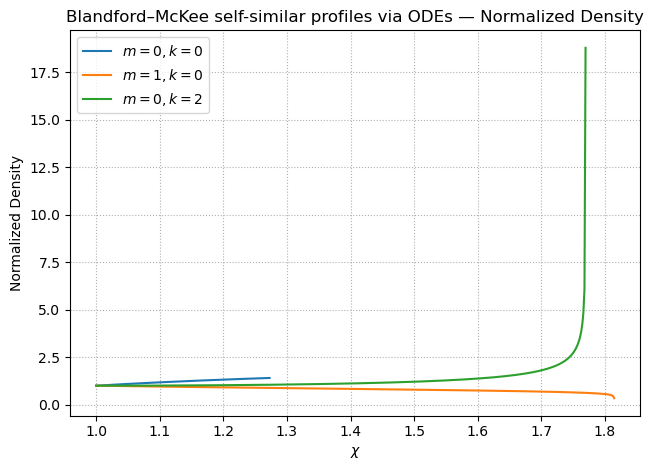

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
from dataclasses import dataclass
from scipy.integrate import solve_ivp

# -------------------------------
# Problem setup / parameters
# -------------------------------
@dataclass
class BMParams:
    m: float = 3.0   # deceleration index (Gamma^2 ∝ t^{-m}); m=3 for adiabatic, k=0
    k: float = 0.0   # external density profile rho ∝ r^{-k}; k=0 uniform
    eps: float = 1e-5  # start just behind the shock at chi = 1 + eps
    chimax: float = 4.0  # target max chi (may stop earlier due to event)
    rtol: float = 1e-6    # slightly looser to start; tighten after it's stable
    atol: float = 1e-9

# -------------------------------
# BM76 ODEs (eqs. 35–37): df/dchi, dg/dchi, dh/dchi
# -------------------------------
def bm76_rhs(chi, y, m, k):
    f, g, h = y

    # Common denominator
    D = (m + 1.0) * (4.0 - 8.0*g*chi + (g**2)*(chi**2))

    # Numerators from BM76 (generic m,k form)
    A = 4.0*(2*(m - 1.0) + k) - (m + k - 4.0)*g*chi
    B = (7.0*m + 3.0*k - 4.0) - (m + 2.0)*g*chi
    C = 2.0*(9.0*m + 5.0*k - 8.0) - 2.0*(5.0*m + 4.0*k - 6.0)*g*chi + (m + k - 2.0)*(g**2)*(chi**2)

    # Convert BM log-derivatives to df/dchi etc.
    df_dchi = f * g * A / D
    dg_dchi = (g**2) * B / D
    dh_dchi = h * g * C / (D * (2.0 - g*chi))
    return np.array([df_dchi, dg_dchi, dh_dchi])

# -------------------------------
# Event: stop before D -> 0 (critical surface)
# -------------------------------
def make_event_stop_before_D_zero(m, k, margin=1e-3):
    """
    Stop when 4 - 8(g*chi) + (g*chi)^2 ~ margin > 0 (approaching 0 from above).
    """
    def event(ch, y):
        _, g, _ = y
        x = g * ch
        return (4.0 - 8.0*x + x*x) - margin
    event.terminal = True
    event.direction = -1.0   # trigger when decreasing through margin
    return event

# Optional extra safety: stop if 2 - g*chi gets small (shouldn't happen for m<=3, k=0)
def make_event_stop_before_h_den(margin=5e-2):
    def event(ch, y):
        _, g, _ = y
        x = g * ch
        return (2.0 - x) - margin
    event.terminal = True
    event.direction = -1.0
    return event

# -------------------------------
# Integrate from chi = 1+eps to chimax (or earlier if event triggers)
# -------------------------------
def integrate_fgH(params):
    chi0 = 1.0 + params.eps
    y0   = np.array([1.0, 1.0, 1.0])  # f(1)=g(1)=h(1)=1

    ev1 = make_event_stop_before_D_zero(params.m, params.k, margin=1e-4)
    ev2 = make_event_stop_before_h_den(margin=1e-4)

    sol = solve_ivp(
        fun=lambda ch, y: bm76_rhs(ch, y, params.m, params.k),
        t_span=(chi0, params.chimax),
        y0=y0,
        method="Radau",                   # Radau handles the stiffness nicely
        dense_output=True,
        rtol=params.rtol,
        atol=params.atol,
        max_step=(params.chimax - chi0)/4000.0,
        events=[ev1, ev2]
    )

    # Accept if solver succeeded OR it hit an event (typical)
    if (not sol.success) and all(len(te)==0 for te in sol.t_events):
        raise RuntimeError(sol.message)
    return sol

# -------------------------------
# Make the Figure 1–style plot using f,g,h
# -------------------------------
def plot_profiles(sol1,sol2,sol3, params1,params2,params3,title_suffix=None):
    # determine the actual end of valid solution
    chi_end1 = sol1.t[-1]
    for te in sol1.t_events:
        if len(te):
            chi_end1 = min(chi_end1, te[-1])

    chi_end2 = sol2.t[-1]
    for te in sol2.t_events:
        if len(te):
            chi_end2 = min(chi_end2, te[-1])

    chi_end3 = sol3.t[-1]
    for te in sol3.t_events:
        if len(te):
            chi_end3 = min(chi_end3, te[-1])


    chi1 = np.logspace(np.log10(1.0+params1.eps), np.log10(chi_end1), 600)
    f1, g1, h1 = sol1.sol(chi1)

    # lock left edge exactly to 1 to remove tiny drift
    # f1 /= f1[0]; g1 /= g1[0]; h1 /= h1[0]

    chi2 = np.logspace(np.log10(1.0+params2.eps), np.log10(chi_end2), 600)
    f2, g2, h2 = sol2.sol(chi2)

    # f2 /= f2[0]; g2 /= g2[0]; h2 /= h2[0]

    chi3 = np.logspace(np.log10(1.0+params3.eps), np.log10(chi_end3), 600)
    f3, g3, h3 = sol3.sol(chi3)

    # f3 /= f3[0]; g3 /= g3[0]; h3 /= h3[0]

    gamma_norm1 = np.sqrt(g1)   # γ/γ2
    p_norm1     = f1            # p/p2
    n_norm1     = h1

    gamma_norm2 = np.sqrt(g2)   # γ/γ2
    p_norm2     = f2            # p/p2
    n_norm2     = h2

    gamma_norm3 = np.sqrt(g3)   # γ/γ2
    p_norm3     = f3            # p/p2
    n_norm3     = h3

    plt.figure(figsize=(6.6,4.8))
    plt.plot(chi1, n_norm1, label=r'$m=0,k=0$')
    plt.plot(chi2, n_norm2,     label=r'$m=1,k=0$')
    plt.plot(chi3, n_norm3,     label=r"$m=0,k=2$")
    plt.xlabel(r'$\chi$')
    plt.ylabel('Normalized Density')
    plt.title(f'Blandford–McKee self-similar profiles via ODEs — Normalized Density')
    plt.grid(True, which='both', ls=':')
    plt.legend()
    plt.tight_layout()
    plt.show()

P1 = BMParams(m=0, k=0)  
sol1 = integrate_fgH(P1)
P2 = BMParams(m=1, k=0)
sol2 = integrate_fgH(P2)
P3 = BMParams(m=0, k=2)
sol3 = integrate_fgH(P3)
plot_profiles(sol1,sol2,sol3, P1,P2,P3)


## Lorentz Factor

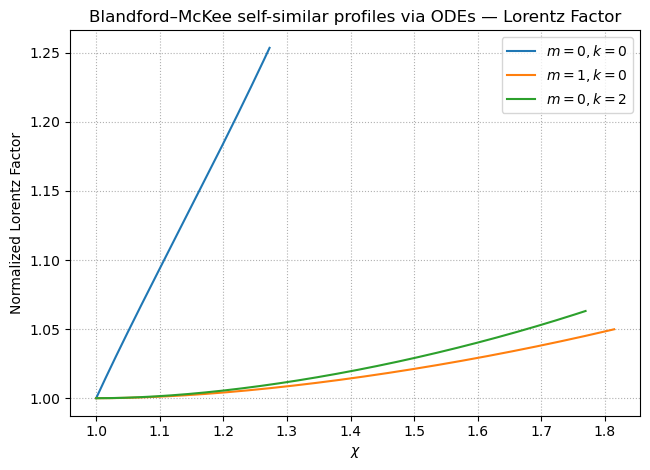

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
from dataclasses import dataclass
from scipy.integrate import solve_ivp

# -------------------------------
# Problem setup / parameters
# -------------------------------
@dataclass
class BMParams:
    m: float = 3.0   # deceleration index (Gamma^2 ∝ t^{-m}); m=3 for adiabatic, k=0
    k: float = 0.0   # external density profile rho ∝ r^{-k}; k=0 uniform
    eps: float = 1e-5  # start just behind the shock at chi = 1 + eps
    chimax: float = 4.0  # target max chi (may stop earlier due to event)
    rtol: float = 1e-6    # slightly looser to start; tighten after it's stable
    atol: float = 1e-9

# -------------------------------
# BM76 ODEs (eqs. 35–37): df/dchi, dg/dchi, dh/dchi
# -------------------------------
def bm76_rhs(chi, y, m, k):
    f, g, h = y

    # Common denominator
    D = (m + 1.0) * (4.0 - 8.0*g*chi + (g**2)*(chi**2))

    # Numerators from BM76 (generic m,k form)
    A = 4.0*(2*(m - 1.0) + k) - (m + k - 4.0)*g*chi
    B = (7.0*m + 3.0*k - 4.0) - (m + 2.0)*g*chi
    C = 2.0*(9.0*m + 5.0*k - 8.0) - 2.0*(5.0*m + 4.0*k - 6.0)*g*chi + (m + k - 2.0)*(g**2)*(chi**2)

    # Convert BM log-derivatives to df/dchi etc.
    df_dchi = f * g * A / D
    dg_dchi = (g**2) * B / D
    dh_dchi = h * g * C / (D * (2.0 - g*chi))
    return np.array([df_dchi, dg_dchi, dh_dchi])

# -------------------------------
# Event: stop before D -> 0 (critical surface)
# -------------------------------
def make_event_stop_before_D_zero(m, k, margin=1e-3):
    """
    Stop when 4 - 8(g*chi) + (g*chi)^2 ~ margin > 0 (approaching 0 from above).
    """
    def event(ch, y):
        _, g, _ = y
        x = g * ch
        return (4.0 - 8.0*x + x*x) - margin
    event.terminal = True
    event.direction = -1.0   # trigger when decreasing through margin
    return event

# Optional extra safety: stop if 2 - g*chi gets small (shouldn't happen for m<=3, k=0)
def make_event_stop_before_h_den(margin=5e-2):
    def event(ch, y):
        _, g, _ = y
        x = g * ch
        return (2.0 - x) - margin
    event.terminal = True
    event.direction = -1.0
    return event

# -------------------------------
# Integrate from chi = 1+eps to chimax (or earlier if event triggers)
# -------------------------------
def integrate_fgH(params):
    chi0 = 1.0 + params.eps
    y0   = np.array([1.0, 1.0, 1.0])  # f(1)=g(1)=h(1)=1

    ev1 = make_event_stop_before_D_zero(params.m, params.k, margin=1e-4)
    ev2 = make_event_stop_before_h_den(margin=1e-4)

    sol = solve_ivp(
        fun=lambda ch, y: bm76_rhs(ch, y, params.m, params.k),
        t_span=(chi0, params.chimax),
        y0=y0,
        method="Radau",                   # Radau handles the stiffness nicely
        dense_output=True,
        rtol=params.rtol,
        atol=params.atol,
        max_step=(params.chimax - chi0)/4000.0,
        events=[ev1, ev2]
    )

    # Accept if solver succeeded OR it hit an event (typical)
    if (not sol.success) and all(len(te)==0 for te in sol.t_events):
        raise RuntimeError(sol.message)
    return sol

# -------------------------------
# Make the Figure 1–style plot using f,g,h
# -------------------------------
def plot_profiles(sol1,sol2,sol3, params1,params2,params3,title_suffix=None):
    # determine the actual end of valid solution
    chi_end1 = sol1.t[-1]
    for te in sol1.t_events:
        if len(te):
            chi_end1 = min(chi_end1, te[-1])

    chi_end2 = sol2.t[-1]
    for te in sol2.t_events:
        if len(te):
            chi_end2 = min(chi_end2, te[-1])

    chi_end3 = sol3.t[-1]
    for te in sol3.t_events:
        if len(te):
            chi_end3 = min(chi_end3, te[-1])


    chi1 = np.logspace(np.log10(1.0+params1.eps), np.log10(chi_end1), 600)
    f1, g1, h1 = sol1.sol(chi1)

    # lock left edge exactly to 1 to remove tiny drift
    # f1 /= f1[0]; g1 /= g1[0]; h1 /= h1[0]

    chi2 = np.logspace(np.log10(1.0+params2.eps), np.log10(chi_end2), 600)
    f2, g2, h2 = sol2.sol(chi2)

    # f2 /= f2[0]; g2 /= g2[0]; h2 /= h2[0]

    chi3 = np.logspace(np.log10(1.0+params3.eps), np.log10(chi_end3), 600)
    f3, g3, h3 = sol3.sol(chi3)

    # f3 /= f3[0]; g3 /= g3[0]; h3 /= h3[0]

    gamma_norm1 = np.sqrt(g1)   # γ/γ2
    p_norm1     = f1            # p/p2
    n_norm1     = h1

    gamma_norm2 = np.sqrt(g2)   # γ/γ2
    p_norm2     = f2            # p/p2
    n_norm2     = h2

    gamma_norm3 = np.sqrt(g3)   # γ/γ2
    p_norm3     = f3            # p/p2
    n_norm3     = h3

    plt.figure(figsize=(6.6,4.8))
    plt.plot(chi1, gamma_norm1, label=r'$m=0,k=0$')
    plt.plot(chi2, gamma_norm2,     label=r'$m=1,k=0$')
    plt.plot(chi3, gamma_norm3,     label=r"$m=0,k=2$")
    plt.xlabel(r'$\chi$')
    plt.ylabel('Normalized Lorentz Factor')
    plt.title(f'Blandford–McKee self-similar profiles via ODEs — Lorentz Factor')
    plt.grid(True, which='both', ls=':')
    plt.legend()
    plt.tight_layout()
    plt.show()

P1 = BMParams(m=0, k=0)  
sol1 = integrate_fgH(P1)
P2 = BMParams(m=1, k=0)
sol2 = integrate_fgH(P2)
P3 = BMParams(m=0, k=2)
sol3 = integrate_fgH(P3)
plot_profiles(sol1,sol2,sol3, P1,P2,P3)
